# Positional Encoding and Group Theory

In [2]:
from IPython.display import Image

## Содержание 

### 1. Positional encoding

### 2. RoPE

### 3. Теория групп, группы и алгебры Ли

### 4. Обобщения RoPE с помощью групп и алгебр Ли

# 1. Positional encoding

Когда мы подаем текст на вход языковой модели, она должна каким-то образом уловить порядок слов. Исходное предложение преобразуется в числовые векторы-токены, а Positional encoding — это специальный метод добавления информации о порядковом номере токена в последовательность. В исходной статье Attention is all you need для этой цели к эмбеддингам токенам прибавлялись синусоидальные кодировки, вычисляемые по порядковому номеру токена в предложении и номеру координаты вектор-токена (опустим эти формулы ввиду их громоздкости).

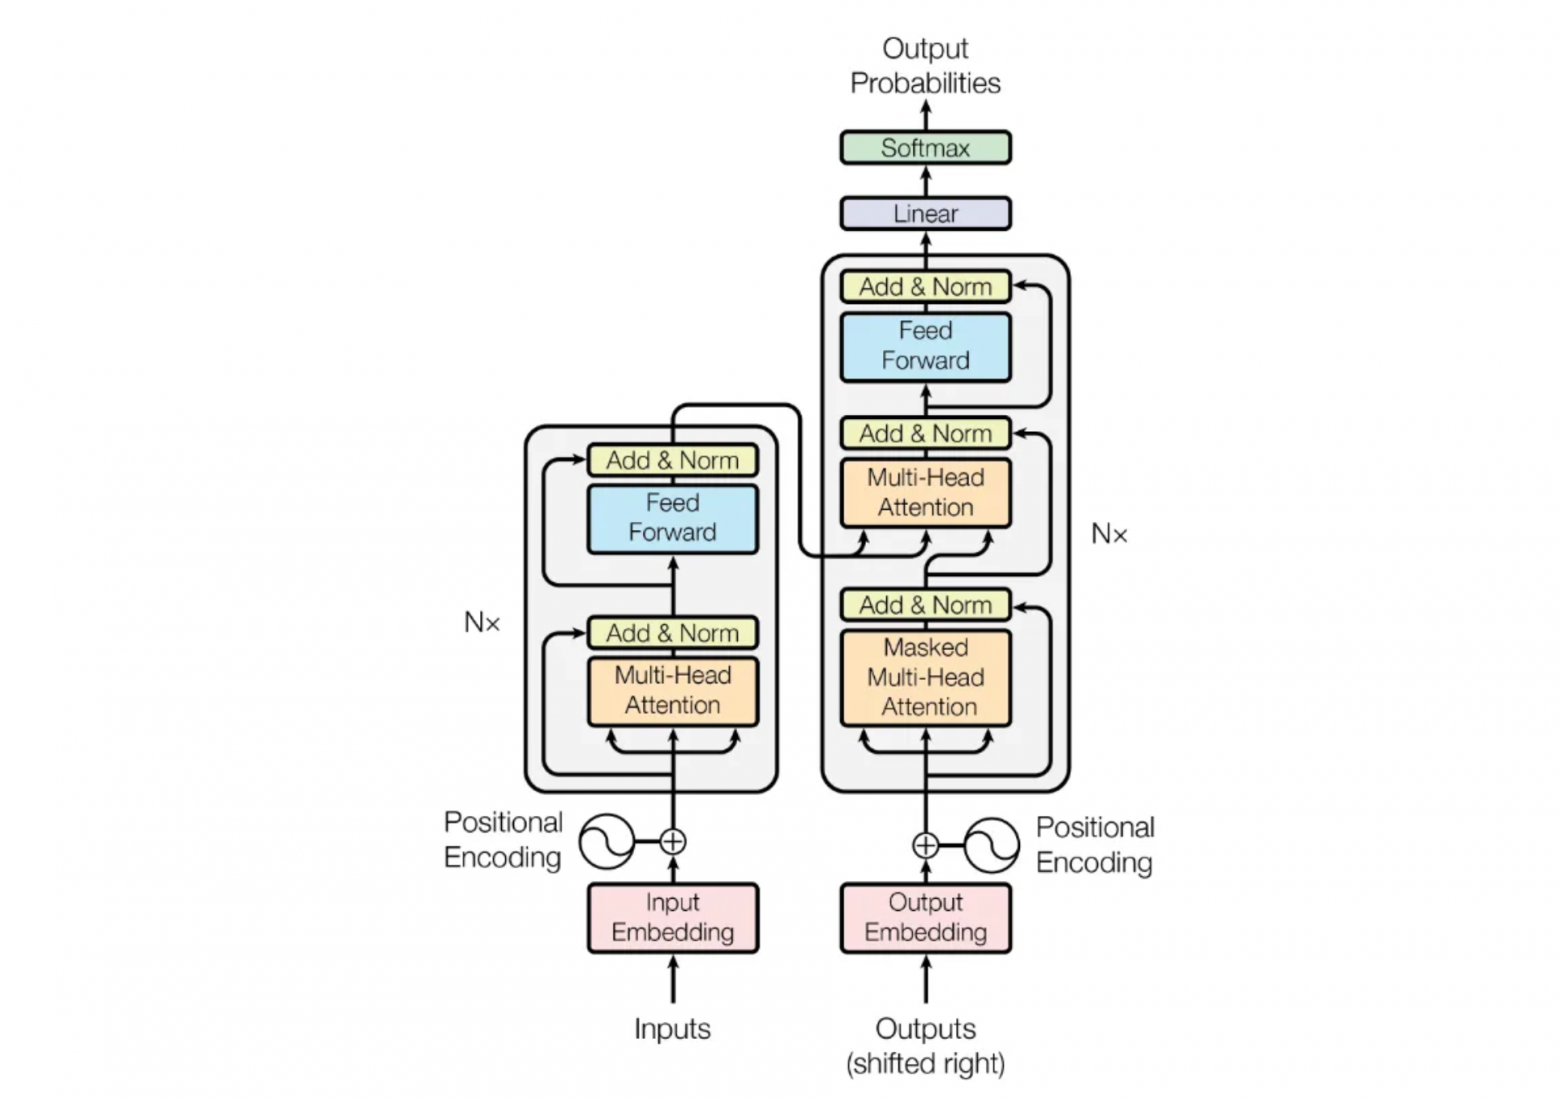

In [5]:
Image('IM_01.png', width=500, height=150 )

Этот Positional Encoding в дальнейшем многократно совершенствовался. На докладе https://vkvideo.ru/live-167479002_456239558 Михаил Васильев (Raiffeisen Bank) провел небольшой обзор эволюции позиционных эмбеддингов. Кстати, всем привет на 1:18:45 (по сути, эта заметка является ответом на заданный там вопрос). Ныне повсеместно используется RoPE - Rotary Position Embedding. Этот метод (после нескольких дополнительных приемов) помог очень сильно расширить окно контекста для языковых моделей. О том, что это за метод, а также о его математической интерпретации и возможных перспективах с этой точки зрения поговорим сегодня. 

# 2. RoPE

В 2021 году выходит статья

https://arxiv.org/pdf/2104.09864

Слабость оригинального энкодинга касалась того, что позиции кодировались абсолютно, в то время как в реальности часто важнее "взаимное расположение смыслов". Для математической формулировки этого свойства нам потребуется вспомнить (или узнать) что такое вращения. Те, кто изучали линейную алгебру, на этом моменте, возможно, напряглись, вспоминая, как будет выглядеть вращение в n-мерном пространстве. Но тут все проще - в методе берутся соседние координаты вектора и вращение будет просто двумерным. 

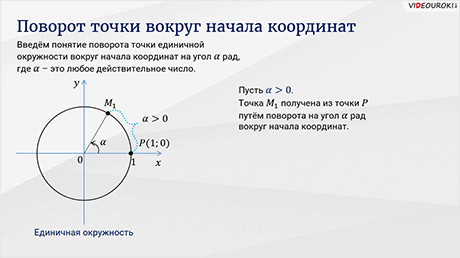

In [6]:
Image('IM_02.jpg', width=500, height=150 )

Вращение плоскости вокруг начала координат - это интуитивно понятный объект: достаточно взять лист бумаги, зафиксировать его в какой-то (нулевой) точке и начать вращать. Композиция двух поворотов снова поворот, причем углы складываются, существует обратный поворот, возвращающий плоскость на место. В матричном виде поворот на угол $\alpha$ выглядит как 

$$\begin{pmatrix} \cos(\alpha) & -\sin(\alpha) \\ \sin(\alpha) & \cos(\alpha) \end{pmatrix}$$

И те, кто знаком с умножением матриц, легко проверят описанные свойства, а также то, что эта матрица реализует именно такое вращение, как на картинке.

### Алгоритм RoPE

**Глобально** это устроено в модели следующим образом:

1. Предложение разбивается на токены: $t_0, t_1, t_2, \dots, t_m, \dots, t_{L-1}$.

2. Каждый токен после предыдущих эмбеддингов и слоёв превращается в свой вектор-токен размерности $d$.

3. При входе в очередной self-attention для каждого вектор-токена $t_m$ вычисляются свои $Q_m$, $K_m$, $V_m$.

4. RoPE применяется к каждому $Q_m$ и $K_n$ отдельно: вектор на позиции m поворачивается на углы, зависящие от m.

5. Затем при подсчете attention для всех индексов m и n считается скалярное произведение $Q_m \cdot K_n$.

**Уточним четвертый шаг:**

4.1. Разбиение на пары: Вектор $Q_m$ размерности d разбивается на d/2 пар $Q_{m, i}$ компонент $(x_{2i}, x_{2i+1})$.

4.2. Углы поворота: Для каждой пары задаётся частота $\theta_i = 10000^{-2i/d}$, $i=0,...,d/2-1$. Для токена на позиции m угол поворота равен $m \cdot \theta_i$ (в стандартной реализации частоты RoPE одинаковы во всех слоях self-attention). Иначе говоря, перед вычислением внимания матрицы
$$R_{m, i} = \begin{pmatrix} \cos(m\theta_i) & -\sin(m\theta_i) \\ \sin(m\theta_i) & \cos(m\theta_i) \end{pmatrix}$$
применяются к парам компонент вектора $Q_{m, i}$, а матрица $R_{n, i}$ - к компонентам $K_{n, i}$ и, таким образом, получаются векторы $\widetilde Q_{m,i} = R_{m, i}Q_{m, i}, \widetilde K_{n,i} = R_{n, i}K_{n, i}$.

4.3. Результат: Скалярное произведение полных d-мерных векторов $\widetilde Q_m^T \cdot \widetilde K_n$ после поворота зависит от n-m (относительной позиции), а не от абсолютных m и n. В самом деле, для соответствующей i-й пары координат $\widetilde Q_{m,i}^T = Q_{m,i}^T R_{m, i}^T$, а матрица $R_{m, i}^T$ соответствует повороту на угол $-m\theta_i$. Значит, 
$$\widetilde Q_{m,i}^T \cdot \widetilde K_{n, i} = Q_{m, i}^T \cdot R_{n-m, i} \cdot K_{n, i} $$ 

### Преимущества RoPE

• Относительность: Внимание естественно учитывает расстояние между токенами.

• Нет дополнительных параметров: В отличие от обучаемых позиционных эмбеддингов, RoPE не добавляет весов.

• Эффективность: Реализуется быстро, часто на уровне ядра.

# 3. Теория групп, группы и алгебры Ли

### Группы

В высшей математике группа - одна из самых первых абстракций, обобщающая целые числа по сложению, либо вещественные ненулевые по умножению. Очень большая часть теории групп завязана на конечные и/или дискретные группы, но сегодня нам потребуется шагнуть в другую сторону.

Группа определяется как множество с операцией ( ⋅ ), удовлетворяющее следующим свойствам.  

    1) замкнутость группы относительно операции умножения — для любых двух элементов группы их произведение является членом той же группы: 
$∀ a , b ∈ G  \quad    a ⋅ b ∈ G$

    2) ассоциативность операции умножения — порядок выполнения умножения несущественен: 
$∀ a , b , c ∈ G  \quad     a ⋅ ( b ⋅ c ) = ( a ⋅ b ) ⋅ c = a ⋅ b ⋅ c$

    3) существование единичного элемента — в группе существует некоторый единичный элемент E, произведение которого с любым элементом a группы даёт тот же самый элемент a: 
$∃ E ∈ G :\quad       ∀ a ∈ G \quad  a ⋅ E = E ⋅ a = a$

    4) существование обратного элемента — для любого элемента a группы существует такой элемент a^{−1}, что их произведение даёт единичный элемент E:
$∀ a ∈ G \quad       ∃ a^{−1} ∈ G :\quad       a ⋅ a^{− 1} = a^{− 1} ⋅ a = E$

**Пример.** Вращения плоскости вокруг нуля также образуют группу естественным образом. По формулам выше эта группа формализуется.

### Группы Ли

Группа Ли - группа, которая одновременно является гладким многообразием. Грубо говоря, у которой операции умножения и взятия обратного элемента являются дифференцируемыми (можно взять по ним производную). 

### Алгебры Ли

Алгеброй Ли называется векторное пространство ${L}$ над полем $K$, снабжённое билинейным отображением

    L^2 → L ,     ( x , y ) ↦ [ x , y ] 

удовлетворяющим следующим двум аксиомам:

    [ x , x ] = 0;
    
    [ x , [ y , z ] ] + [ y , [ z , x ] ] + [ z , [ x , y ] ] = 0 (тождество Якоби).

**Пример.** ${\displaystyle [x,y]=xy-yx}$

Внезапно, если мы возьмем касательное пространство к группе Ли в единичном элементе, мы получим алгебру Ли. В ряде случаев по алгебре Ли группа Ли также восстанавливается - это называется экспонентой и зачастую это в прямом смысле экспонента (правда, матричная, задаваемая формулой Тейлора, в которую подставлены матрицы). 

# 4. Обобщения RoPE с помощью групп и алгебр Ли

В 2026 году на конференции ICLR был представлен алгоритм GRAPE, обобщающий вращения RoPE и аддитивные смещения логитов на группы Ли 

https://proceedings.iclr.cc/paper_files/paper/2026/file/5cb58625f49ddf70fe2d527e9e4bbae5-Paper-Conference.pdf

Сосредоточимся на вращениях. Те люди, которые напряглись в пункте 2, могут обрадоваться своей математической интуиции - в статье вращения вокруг попарно связанных плоскостей обобщаются на обучаемые вращения, выходящие за рамки фиксированных координатных пар. Более того, любое вращение действительно распадается в блочно-диагональный вид двумерных матриц вращения, а также 1 (и четное количество -1, которые являются частным случаем вращения, если брать их попарно), как следует из теоремы о вещественной форме ортогональных операторов.

$$A = diag(R_1, ..., R_k, 1,...1)$$

Далее идет минутка математики, обосновывающая алгоритм. Алгоритмическая часть и к чему это привело - в последних двух абзацах.

## \start mathematics

**А причем тут группы и алгебры Ли?**

SO(d) — это специальная ортогональная группа: группа всех вращений d-мерного евклидова пространства вокруг начала координат. Формально:

$SO(d)=\{R\in \mathbb R^{d\times d}\mid R^\top R=I,\ \det R=1\}.$
 
Условие $R^\top R=I$ означает, что R сохраняет длины и скалярное произведение, а $\det R=1$ отсекает отражения, что и интерпретируется как обобщенное вращение в многомерном случае. Это группа Ли: она одновременно является группой и гладким многообразием.
 
Алгебра Ли $\mathfrak{so}(d)$ — это касательное пространство к $SO(d)$ в единице, «инфинитезимальные вращения», или генераторы вращений. Для матричных групп её можно описать как множество матриц X, для которых $\exp(tX)\in SO(d)$ при всех t. Это в точности кососимметричные матрицы:

$\mathfrak{so}(d)=\{X\in \mathbb R^{d\times d}\mid X^\top=-X\}$.
 
Скобка Ли в ней — обычный коммутатор:

$[X,Y]=XY-YX$.

**Утверждение:** Касательные векторы SO(d) - кососимметричные матрицы.

**Доказательство** Пусть $\gamma(t)\in SO(d), \gamma(0)=I, \gamma'(0)=X$ (это и есть определение касательного вектора). 
Так как $\gamma(t)\in SO(d)$, выполнено

$\gamma(t)^\top \gamma(t)=I$.
 
Дифференцируем это равенство по t:

$\gamma'(t)^\top \gamma(t)+\gamma(t)^\top \gamma'(t)=0.$
 
При t=0:

$\gamma'(0)^\top \gamma(0)+\gamma(0)^\top \gamma'(0)=0$.
 
Учитывая $\gamma(0)=I, \gamma'(0)=X,$ получаем

$X^\top+X=0$,
 
то есть

$X^\top=-X$.
 
Значит, любой касательный вектор к SO(d) в единице является кососимметричной матрицей. **Доказательство окончено**.

Утверждение верно и в обратную сторону. Связь даёт экспоненциальное отображение:

$\exp:\mathfrak{so}(d)\to SO(d),\qquad 
\exp(X)=\sum_{k=0}^\infty \frac{X^k}{k!}.$
 
Именно это используется в GRAPE: берётся d/2 произвольных генераторов $L\in\mathfrak{so}(d)$ ранга 2, и позиционное кодирование задаётся как произведение операторов вида

$G(n)=\exp(n\omega L)$ для некоторого $\omega$.

## \end mathematics

## GRAPE-M

После некоторого математического формализма, для любых двух непараллельных векторов мы получаем вращение в плоскости, натянутой на эти векторы и соответствующий оператор G, играющий ту же роль, что матрицы $R_{m, i}$. Самое важное, что построенные операторы имеют то же свойство, за которое мы любим RoPE

$\widetilde Q^⊤_m \widetilde K_n = Q^⊤_m G^⊤(m)G(n)K_n = Q^⊤_m G(n − m)K_n$ 

Именно этот математический формализм и формула Родригеса, сокращающая экспоненциальный ряд до трех слагаемых, позволяет аккуратно встроить обучающиеся векторы в функцию потерь и определять, вокруг чего и как мы будем вращаться.

## А что в итоге?

Хотя это обобщение (пока?) не стало новым SOTA, оно дало интересную интерпретацию происходящего в RoPE. В работе также была разработана аддитивная поправка, которая уже дала прирост в качестве на пару процентов, но она имеет природу, отличную от RoPE и требует иного подхода. 